In [ ]:
import os
import json
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Classroom', 'f2023010568 mid hareem tahir.gdoc', 'Cv about.pdf', 'Untitled document (7).gdoc', 'f2023105068 cyber lab.gdoc', 'Untitled document (6).gdoc', 'Untitled document (5).gdoc', 'DOC-20260515-WA0035..pdf', 'Mycv (1).pdf', 'Mycv.pdf', 'sna assign 1.gdoc', 'F2023105068 ossdasg2.gdoc', 'f2023105068 graded lab.gdoc', '21 century assignment 1', 'Untitled document (4).gdoc', 'f2023105068 hareem tahir assignment 1.gdoc', 'Untitled document (3).gdoc', 'Y2 presentation list.xlsx', '21 century asg 2', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Sna y2 presentation list.gsheet', 'Hareem_Tahir_CV.pdf', 'Colab Notebooks', 'Untitled document.gdoc', '13-14--Machine Learning Lecture # 13 and 14.gdoc', 'BRISC_ML_Project']


In [3]:
import os

project_dir = "/content/drive/MyDrive/BRISC_ML_Project"

print(os.listdir(project_dir))

['notebooks', 'features', 'results']


In [4]:
features_dir = "/content/drive/MyDrive/BRISC_ML_Project/features"

print(os.listdir(features_dir))

['X_test_pca.npy', 'y_test.npy', 'y_train.npy', 'X_train_pca.npy', 'pca_model.pkl', 'knn_model.pkl', 'label_map.json', 'random_forest_model.pkl']


In [5]:
import os
import numpy as np

features_dir = "/content/drive/MyDrive/BRISC_ML_Project/features"

X_train_pca = np.load(
    os.path.join(features_dir, "X_train_pca.npy")
)

X_test_pca = np.load(
    os.path.join(features_dir, "X_test_pca.npy")
)

y_train = np.load(
    os.path.join(features_dir, "y_train.npy")
)

y_test = np.load(
    os.path.join(features_dir, "y_test.npy")
)

print("X_train:", X_train_pca.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test_pca.shape)
print("y_test:", y_test.shape)

X_train: (5000, 1485)
y_train: (5000,)
X_test: (1000, 1485)
y_test: (1000,)


In [6]:
import json

with open(
    os.path.join(features_dir, "label_map.json"),
    "r"
) as f:
    label_map = json.load(f)

classes = [
    class_name
    for class_name, label in sorted(
        label_map.items(),
        key=lambda x: int(x[1])
    )
]

print("Classes:", classes)

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

print(dt)

DecisionTreeClassifier(random_state=42)


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [5, 10, 20, None]
}

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_dt.fit(
    X_train_pca,
    y_train
)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None]}, scoring='f1_macro')

In [9]:
print("Best Parameters:", grid_dt.best_params_)

print("Best CV Macro F1:", grid_dt.best_score_)

Best Parameters: {'max_depth': 5}
Best CV Macro F1: 0.4775883952597862


In [10]:
best_dt = grid_dt.best_estimator_

print(best_dt)

DecisionTreeClassifier(max_depth=5, random_state=42)


In [11]:
y_pred_dt = best_dt.predict(X_test_pca)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_dt))

Predictions completed!
Number of predictions: 1000


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [14]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="macro",
    zero_division=0
)

print(f"Accuracy: {dt_accuracy * 100:.2f}%")
print(f"Macro Precision: {dt_precision * 100:.2f}%")
print(f"Macro Recall: {dt_recall * 100:.2f}%")
print(f"Macro F1: {dt_f1 * 100:.2f}%")

Accuracy: 66.70%
Macro Precision: 68.70%
Macro Recall: 68.00%
Macro F1: 67.14%


In [15]:
dt_results = {
    "Model": "Decision Tree",
    "Best Parameters": grid_dt.best_params_,
    "Accuracy": dt_accuracy,
    "Macro Precision": dt_precision,
    "Macro Recall": dt_recall,
    "Macro F1": dt_f1
}

print(dt_results)

{'Model': 'Decision Tree', 'Best Parameters': {'max_depth': 5}, 'Accuracy': 0.667, 'Macro Precision': 0.6870212342146382, 'Macro Recall': 0.6799672835013271, 'Macro F1': 0.6713635632738382}


In [18]:
import joblib
joblib.dump(
    best_dt,
    "/content/drive/MyDrive/BRISC_ML_Project/features/decision_tree_model.pkl"
)

print("Decision Tree model saved successfully!")

Decision Tree model saved successfully!


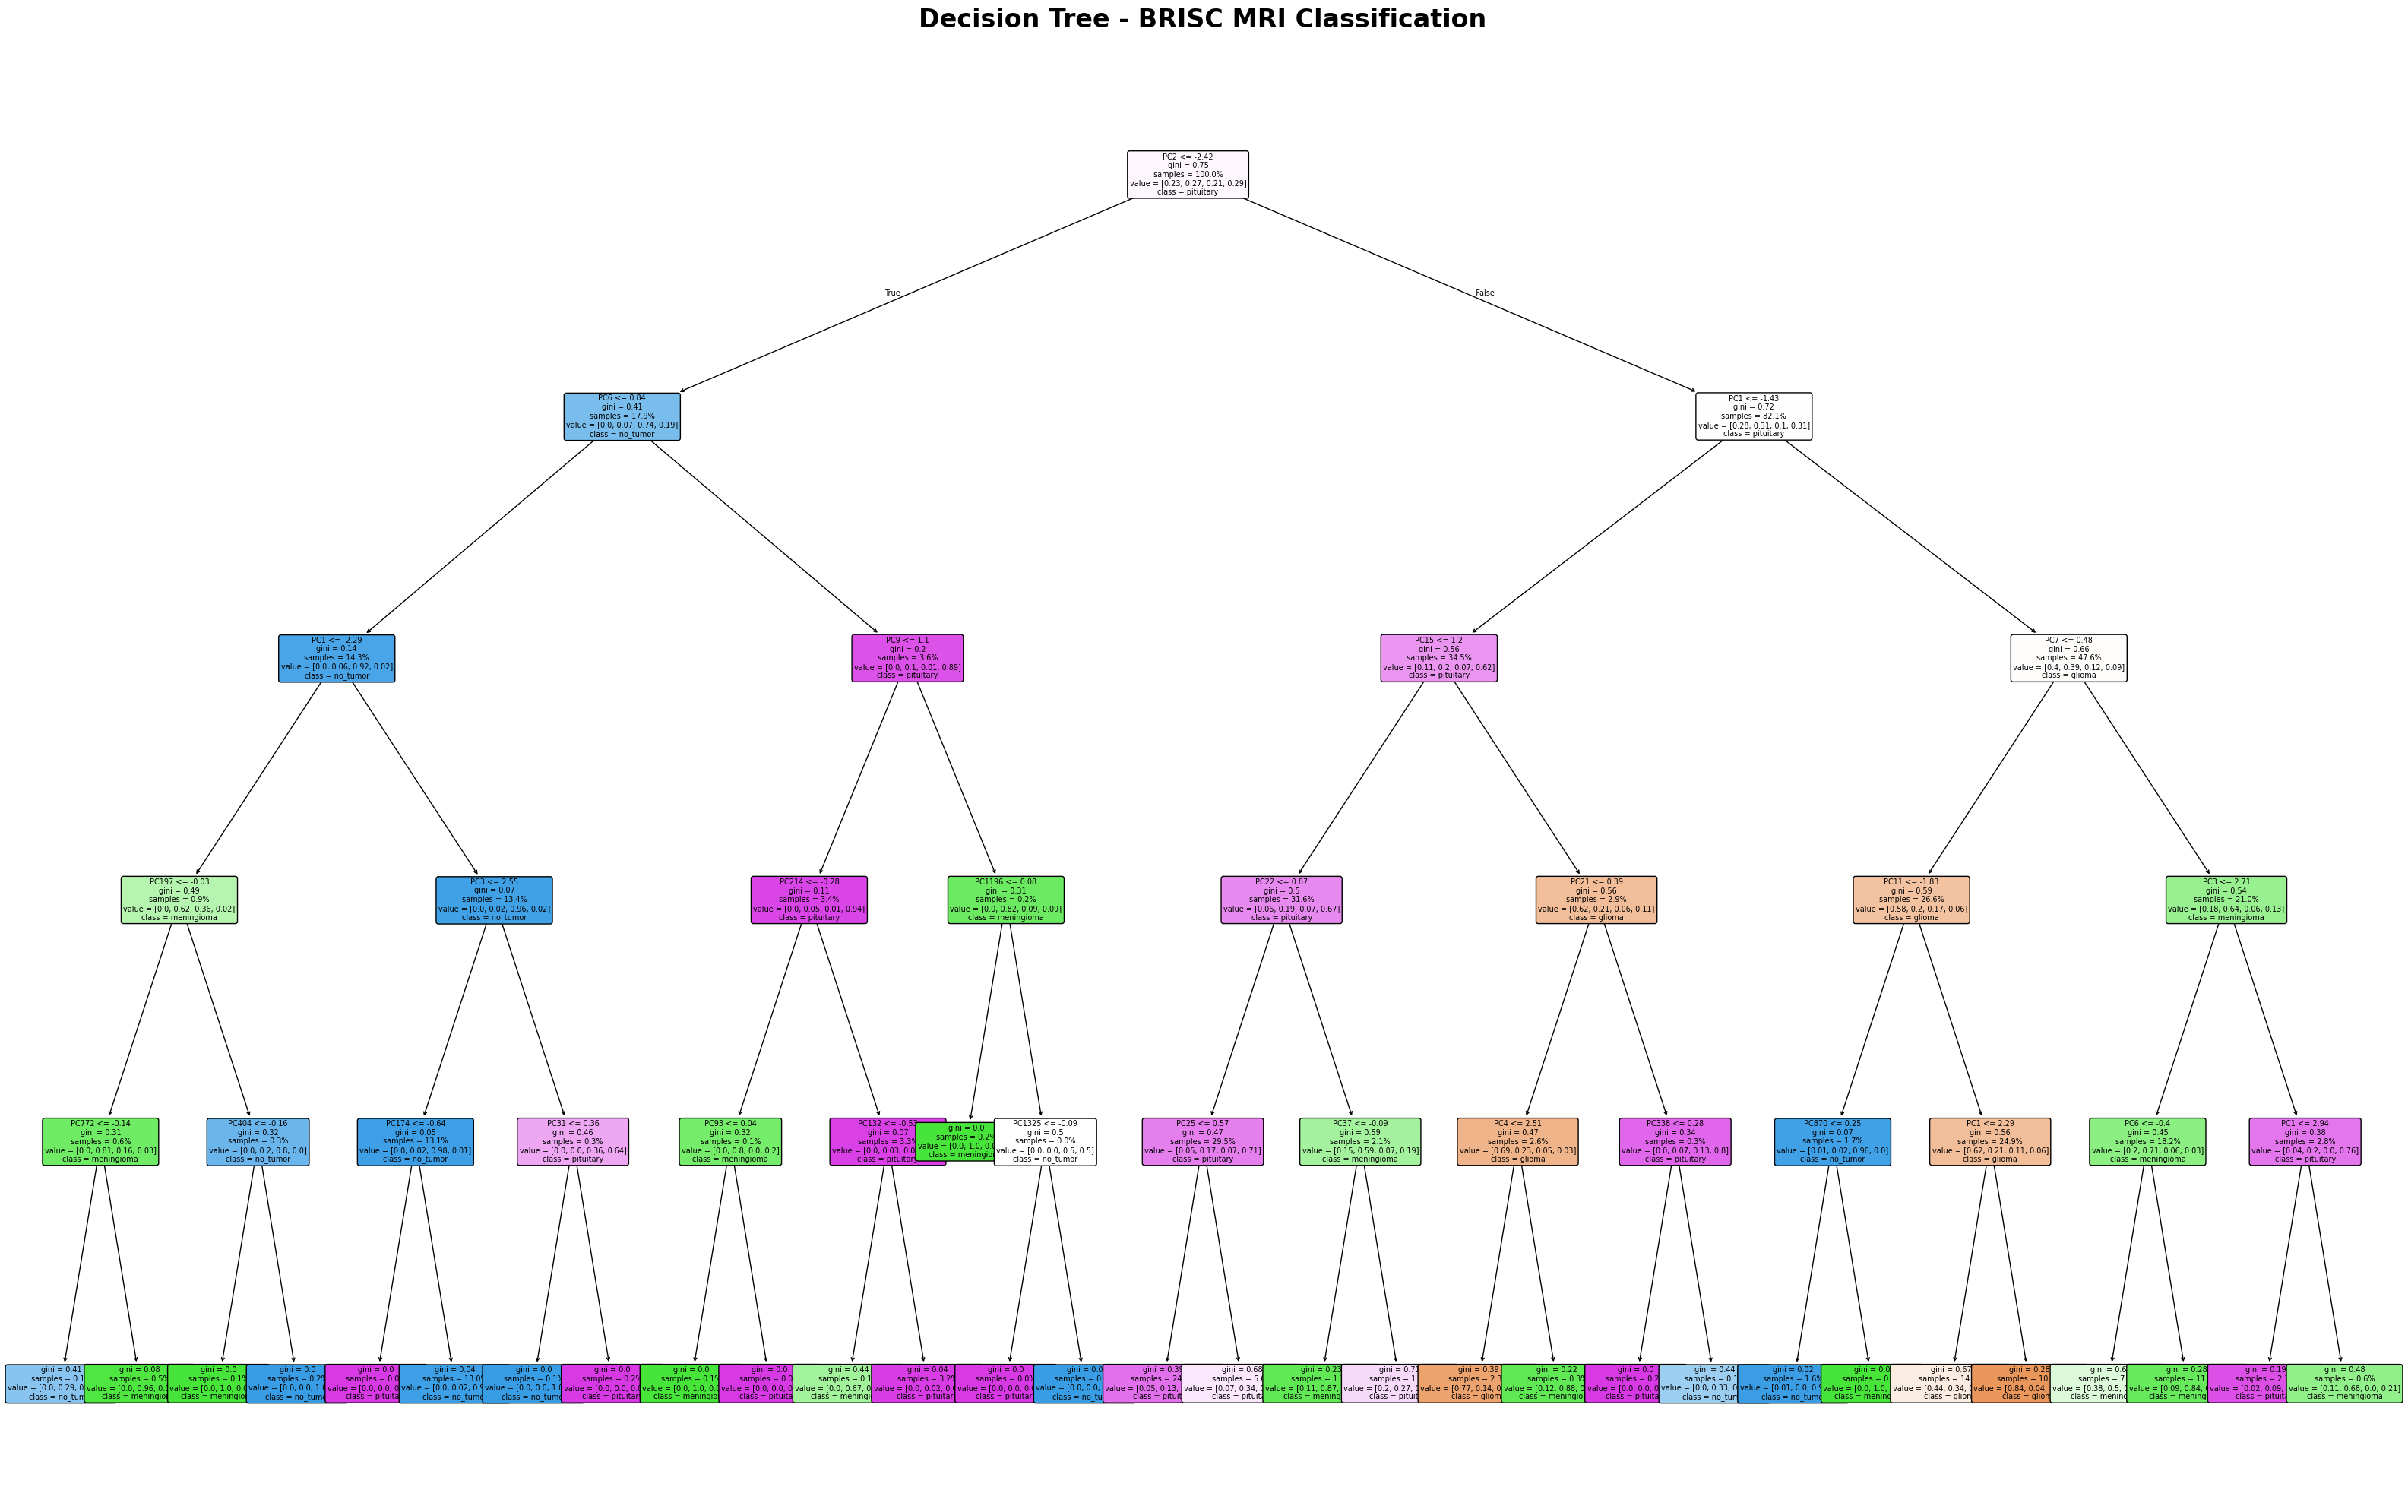

🌸🌳 Decision Tree saved successfully!
/content/drive/MyDrive/BRISC_ML_Project/graphs/decision_tree_tall_pastel.png


In [29]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import os

# ==============================
# SAVE FOLDER
# ==============================

graphs_dir = "/content/drive/MyDrive/BRISC_ML_Project/graphs"
os.makedirs(graphs_dir, exist_ok=True)


# ==============================
# PASTEL COLORS
# ==============================

pastel_colors = [
    "#F8C8D8",   # Pastel Pink
    "#FFF1B8",   # Butter Yellow
    "#CFE8F5",   # Light Blue
    "#D9F2D0"    # Light Green
]


# ==============================
# CREATE TREE
# ==============================

fig, ax = plt.subplots(figsize=(32, 20))

plot_tree(
    best_dt,

    feature_names=[
        f"PC{i+1}"
        for i in range(X_train_pca.shape[1])
    ],

    class_names=classes,

    filled=True,
    rounded=True,

    proportion=True,
    precision=2,

    fontsize=7,

    ax=ax
)


# ==============================
# PASTEL NODE COLORS
# ==============================

tree = best_dt.tree_

for i, patch in enumerate(ax.patches):

    class_index = tree.value[i][0].argmax()

    patch.set_facecolor(
        pastel_colors[class_index % 4]
    )

    patch.set_edgecolor("#777777")
    patch.set_linewidth(1.2)


# ==============================
# TITLE
# ==============================

ax.set_title(
    "Decision Tree - BRISC MRI Classification",
    fontsize=24,
    fontweight="bold",
    pad=25
)


# ==============================
# CLEAN LAYOUT
# ==============================

ax.axis("off")

plt.tight_layout()


# ==============================
# SAVE IMAGE
# ==============================

tree_path = os.path.join(
    graphs_dir,
    "decision_tree_tall_pastel.png"
)

plt.savefig(
    tree_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print("🌸🌳 Decision Tree saved successfully!")
print(tree_path)